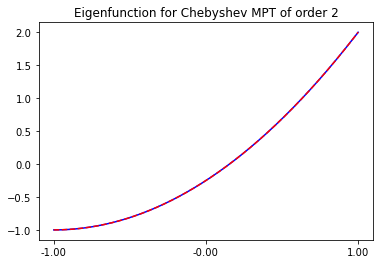

In [2]:
%run ../python/chebyshevMPT.py
from numpy import linspace, mean
from numpy.polynomial import Polynomial
import sympy as sp
import matplotlib.pyplot as plt
from functools import partial


order = 2
chebym = ChebyshevMPT(order)
u = linspace(-1.0+1e-8,1.0-1e-8,num=1000, endpoint=True)

# Proposed eigenfunction as polynomials
p = Polynomial([-1, 6, 3])
d = p.degree()
lambdad = 1/(2**d)

Pf = [chebym.FP(p,u1) for u1 in u]
flam = [lambdad*p(u1) for u1 in u]
fig, ax = plt.subplots()
ax.plot(u,Pf, label='Pf', color='blue')
ax.plot(u, flam, label='$\\lambda f$', color='red', linestyle="--")
ax.set_title(f"Eigenfunction for Chebyshev MPT of order {order}")
ax.set_xticks(chebym.extrema)
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()

# print([sin(k*pi/4) for k in [1, 3, 5, 7]])
# print([cos(k*pi/4) for k in [1, 3, 5, 7]])


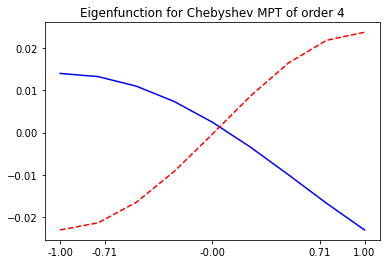

In [14]:
# This chunk implements the spectral decomposition provided
# by Claude 5.0 on September 13, 2026.
#
# Note that there is a sign difference on x in the pB
# function relative to the Claude guidance. 


#def pB(x,deg):
#    return (sp.bernoulli(2*deg,(1-x)/2) -
#              deg*sp.euler(2*deg-1,(1-x)/2))

# In this version, deg is the degree of the polynomial 
def pB(x,deg):
    y = (1-x)/2
    return (2**deg)*sp.bernoulli(deg,y/2)

d = 6
Pf = [chebym.FP(partial(pB, deg=d),u1) for u1 in u]
flam = [(0.5**d)*pB(u1,d) for u1 in u]

fig, ax = plt.subplots()
ax.plot(u,Pf, label='Pf', color='blue')
ax.plot(u, flam, label='$\\lambda f$', color='red', linestyle="--")
ax.set_title(f"Eigenfunction for Chebyshev MPT of order {order}")
ax.set_xticks(chebym.extrema)
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()


-0.0007281818181818153
-0.0007281818181818182


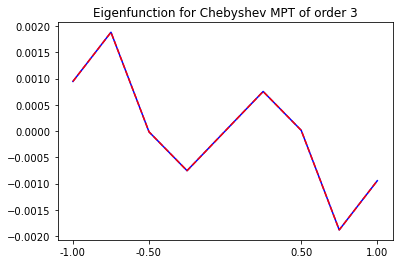

In [4]:
# Case n=3:
order = 3
chebym = ChebyshevMPT(order)

# Proposed eigenfunction as polynomials
eigfunclist = [[1], [0, 1], [-1/3, 0, 1], [0, 0, 0, 1],
               [3/10, 0, -3/2, 0, 1],
               [0, 3/11, 0, -4/3, 0, 1]]
eigvallist = [1, -1/2, -1/8, -1/8, 1/16, 1/64]
d = 5
p = Polynomial(eigfunclist[d])
lambdad = eigvallist[d]

print(chebym.FP(p,0.6))
print(lambdad*p(0.6))

u = linspace(-1.0+1e-6,1.0-1e-6,num=9, endpoint=True)
Pf = [chebym.FP(p,u1) for u1 in u]
flam = [lambdad*p(u1) for u1 in u]

fig, ax = plt.subplots()
ax.plot(u,Pf, label='Pf', color='blue')
ax.plot(u, flam, label='$\\lambda f$', color='red', linestyle="--")
ax.set_title(f"Eigenfunction for Chebyshev MPT of order {order}")
ax.set_xticks(chebym.extrema)
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()


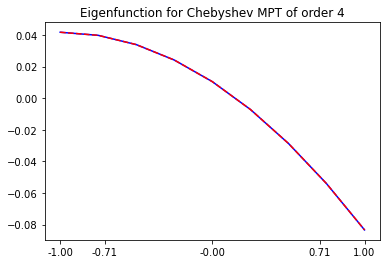

In [21]:
order = 4
chebym = ChebyshevMPT(order)
#def pB(x,deg):
#    r = 2*(2**0.5)
#    return (sp.bernoulli(2*deg,(1-x)/r) -
#              deg*sp.euler(2*deg-1,(1-x)/r))

#p = Polynomial([0, 0, 1])
#d = p.degree()
#lambdad = 1/(4**d)

#def pB(x):
#    return x-0.5*(x**2)

def pB4(x,deg):
    y = (1-x)/2
    return (2**deg)*sp.bernoulli(deg,y/2)


def g(x):
    y=(1-x)/2
    return pB4(y,4) - (2/7)*pB4(y,2)

d = 2
# Pf = [chebym.FP(partial(pB4, deg=d),u1) for u1 in u]
# flam = [(0.25**d)*pB4(g) for u1 in u]
Pf = [chebym.FP(partial(pB4, deg=d),u1) for u1 in u]
flam = [-(0.5**(3*d/2))*pB4(u1,d) for u1 in u]

#flam = [(0.5-0.5*u1)-0.125*(1-u1)**2 for u1 in u]
#flam = [-lambdad*pB(u1) for u1 in u]
fig, ax = plt.subplots()
ax.plot(u,Pf, label='Pf', color='blue')
ax.plot(u, flam, label='$\\lambda f$', color='red', linestyle="--")
ax.set_title(f"Eigenfunction for Chebyshev MPT of order {order}")
ax.set_xticks(chebym.extrema)
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()

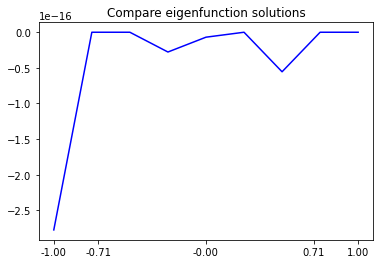

In [11]:

def pBE(x,deg):
    return (sp.bernoulli(2*deg,(1-x)/2) -
              deg*sp.euler(2*deg-1,(1-x)/2))

def pBhalf(x,deg):
    y = (1-x)/2
    return (2**deg)*sp.bernoulli(deg,y/2)

dval1 = [pBE(u1,2)-pBhalf(u1,4) for u1 in u]

fig, ax = plt.subplots()
ax.plot(u,dval1, label='difference', color='blue')
ax.set_title(f"Compare eigenfunction solutions")
ax.set_xticks(chebym.extrema)
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()
